In [ ]:
# ============================================================================
# REAL-WORLD DATA ANALYSIS: MARKETING CAMPAIGN DATASET
# Performance Marketing Dashboard using Python (Pandas, Matplotlib, Seaborn)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set styling for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("REAL-WORLD DATA ANALYSIS: MARKETING CAMPAIGN DATASET")
print("Performance Marketing Dashboard")
print("=" * 80)

REAL-WORLD DATA ANALYSIS: MARKETING CAMPAIGN DATASET
Performance Marketing Dashboard


In [ ]:
# ============================================================================
# PART 1: DATA UNDERSTANDING & LOADING
# ============================================================================

print("\n" + "=" * 80)
print("PART 1: DATA UNDERSTANDING & LOADING")
print("=" * 80)

# Load the dataset from Kaggle
url = "https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign"
# Since we need to load from local, use this code:
from google.colab import files
print("\n Upload your marketing_campaign.csv file:")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(csv_file)

print(f"\n Dataset loaded successfully!")
print(f"\n Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Display first few rows
print("\n First 5 Rows of the Dataset:")
print(df.head())

# Display column names and data types
print("\n Column Names and Data Types:")
print(df.dtypes)

# Display dataset info
print("\n Dataset Info:")
print(df.info())

# Generate statistical summary
print("\n Statistical Summary:")
print(df.describe())

# Check for missing values
print("\n Missing Values:")
print(df.isnull().sum())

# Display unique values in key columns
print("\n Unique Values in Key Columns:")
for col in df.columns[:10]:
    print(f"  {col}: {df[col].nunique()} unique values")

# Explain each column
print("\n Column Explanations:")
column_explanations = {
    "ID": "Unique customer identifier",
    "Year_Birth": "Birth year of the customer",
    "Income": "Annual income of the customer",
    "Recency": "Days since last purchase",
    "MntWines": "Amount spent on wine products",
    "MntFruits": "Amount spent on fruit products",
    "MntMeatProducts": "Amount spent on meat products",
    "MntFishProducts": "Amount spent on fish products",
    "MntSweetProducts": "Amount spent on sweet products",
    "MntGoldProds": "Amount spent on gold products",
    "NumDealsPurchases": "Number of purchases made with discount",
    "NumWebPurchases": "Number of purchases made on website",
    "NumCatalogPurchases": "Number of purchases made through catalog",
    "NumStorePurchases": "Number of purchases made in-store",
    "NumWebVisitsMonth": "Number of website visits per month",
    "AcceptedCmp1": "Customer accepted offer in campaign 1",
    "AcceptedCmp2": "Customer accepted offer in campaign 2",
    "AcceptedCmp3": "Customer accepted offer in campaign 3",
    "AcceptedCmp4": "Customer accepted offer in campaign 4",
    "AcceptedCmp5": "Customer accepted offer in campaign 5",
    "Response": "Customer accepted offer in last campaign",
    "Complain": "Number of complaints filed",
    "Country": "Country of residence",
    "Dt_Customer": "Date customer enrolled",
}

for col, explanation in column_explanations.items():
    if col in df.columns:
        print(f"  • {col}: {explanation}")


PART 1: DATA UNDERSTANDING & LOADING

 Upload your marketing_campaign.csv file:


Saving marketing_campaign.csv to marketing_campaign (2).csv

 Dataset loaded successfully!

 Dataset Shape: 2240 rows × 1 columns

 First 5 Rows of the Dataset:
  ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response
0  5524;1957;Graduation;Single;58138;0;0;2012-09-...                                                                                                                                                                                                                                                                                                                      
1  2174;1954;Graduation;Single;46344;1;1;2014-03-...                                                             

In [ ]:
# ============================================================================
# PART 2: DATA CLEANING
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: DATA CLEANING")
print("=" * 80)

# FIX: Re-load the DataFrame with the correct separator to resolve KeyError
df = pd.read_csv(csv_file, sep=';')

# Create a copy for cleaning
df_clean = df.copy()

print(f"\n Original dataset shape: {df_clean.shape}")

# 1. Handle missing values
print("\n Handling Missing Values...")
print(f"Missing values before cleaning:\n{df_clean.isnull().sum()}")

# Fill missing Income with median (if exists)
if df_clean['Income'].isnull().any():
    median_income = df_clean['Income'].median()
    df_clean['Income'].fillna(median_income, inplace=True)
    print(f"   Filled Income missing values with median: {median_income}")

# Fill other missing values
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
print("   Filled numeric missing values with median")

# 2. Remove duplicates
print("\n Removing Duplicates...")
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = duplicates_before - len(df_clean)
print(f"   Removed {duplicates_removed} duplicate records")

# 3. Clean column names (remove spaces, standardize)
print("\n Cleaning Column Names...")
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
print("   Column names standardized")
print(f"  New columns: {list(df_clean.columns[:5])}...")

# 4. Convert data types
print("\n Converting Data Types...")

# Convert Year_Birth to Age
if 'year_birth' in df_clean.columns:
    current_year = 2024
    df_clean['age'] = current_year - df_clean['year_birth']
    df_clean = df_clean.drop('year_birth', axis=1)
    print(f"   Converted year_birth to age")

# Convert Dt_Customer to datetime if exists
if 'dt_customer' in df_clean.columns:
    df_clean['dt_customer'] = pd.to_datetime(df_clean['dt_customer'], errors='coerce')
    print(f"   Converted dt_customer to datetime")

# 5. Create Sales/Revenue metric from product spending
print("\n Creating Sales/Revenue Metrics...")
product_columns = [col for col in df_clean.columns if col.startswith('mnt')]
df_clean['total_spending'] = df_clean[product_columns].sum(axis=1)
df_clean['total_purchases'] = df_clean[[col for col in df_clean.columns if 'num' in col and 'purchases' in col]].sum(axis=1)
print(f"   Created total_spending column")
print(f"   Created total_purchases column")

# 6. Create Product Categories from spending columns
print("\nCreating Product Category Metrics...")
df_clean['wines_pct'] = (df_clean.get('mntwines', 0) / (df_clean['total_spending'] + 1)) * 100
df_clean['meats_pct'] = (df_clean.get('mntmeatproducts', 0) / (df_clean['total_spending'] + 1)) * 100
df_clean['fruits_pct'] = (df_clean.get('mntfruits', 0) / (df_clean['total_spending'] + 1)) * 100
df_clean['fish_pct'] = (df_clean.get('mntfishproducts', 0) / (df_clean['total_spending'] + 1)) * 100
df_clean['sweets_pct'] = (df_clean.get('mntsweetproducts', 0) / (df_clean['total_spending'] + 1)) * 100
df_clean['gold_pct'] = (df_clean.get('mntgoldprods', 0) / (df_clean['total_spending'] + 1)) * 100
print(f"   Created product category percentages")

# 7. Create Campaign Response Metric
if 'response' in df_clean.columns:
    campaign_cols = [col for col in df_clean.columns if col.startswith('acceptedcmp')]
    df_clean['total_campaigns_accepted'] = df_clean[campaign_cols].sum(axis=1)
    df_clean['campaign_response_rate'] = (df_clean['total_campaigns_accepted'] > 0).astype(int)
    print(f"   Created campaign response metrics")

# 8. Create Regional Segments (if country data exists, use it; else create proxy)
print("\n Creating Regional Segments...")
if 'country' in df_clean.columns:
    print(f"   Using country as region: {df_clean['country'].nunique()} unique regions")
    df_clean['region'] = df_clean['country']
else:
    # Create proxy regions based on Income quartiles
    df_clean['region'] = pd.qcut(df_clean['income'], q=4, labels=['Low Income', 'Mid-Low Income', 'Mid-High Income', 'High Income'])
    print(f"   Created region proxy based on income segments")

# 9. Create Income Segments
print("\n Creating Customer Segments...")
if 'income' in df_clean.columns:
    df_clean['income_segment'] = pd.qcut(df_clean['income'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
    print(f"   Created income segments")

# 10. Create a synthetic date column for time-series analysis
print("\n Creating Temporal Data...")
if 'dt_customer' in df_clean.columns:
    df_clean['signup_month'] = df_clean['dt_customer'].dt.to_period('M')
    df_clean['signup_year'] = df_clean['dt_customer'].dt.year
else:
    df_clean['signup_month'] = pd.Period('2024-01', freq='M')
    df_clean['signup_year'] = 2024
print(f"   Created temporal features")

print(f"\n Dataset shape after cleaning: {df_clean.shape}")
print(f" Cleaned dataset ready!")

# Save cleaned dataset
cleaned_csv_path = 'marketing_campaign_cleaned.csv'
df_clean.to_csv(cleaned_csv_path, index=False)
print(f"\n Cleaned dataset saved as '{cleaned_csv_path}'")

# Display cleaned data summary
print("\n Cleaned Data Sample:")
print(df_clean.head())


PART 2: DATA CLEANING

 Original dataset shape: (2240, 29)

 Handling Missing Values...
Missing values before cleaning:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
   Filled Income missing values with median: 51381.5
   Filled numeric missing values with median

 Removing Dup

In [ ]:
# ============================================================================
# PART 3: DATA ANALYSIS (USING PANDAS)
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: DATA ANALYSIS (USING PANDAS)")
print("=" * 80)

# 1. Total Sales/Revenue
print("\n REVENUE METRICS")
print("-" * 80)
total_revenue = df_clean['total_spending'].sum()
print(f"  Total Revenue (Total Spending): ${total_revenue:,.2f}")

# 2. Average Sales
average_revenue = df_clean['total_spending'].mean()
print(f"  Average Revenue per Customer: ${average_revenue:,.2f}")

# 3. Revenue statistics
print(f"  Median Revenue per Customer: ${df_clean['total_spending'].median():,.2f}")
print(f"  Maximum Revenue per Customer: ${df_clean['total_spending'].max():,.2f}")
print(f"  Minimum Revenue per Customer: ${df_clean['total_spending'].min():,.2f}")
print(f"  Standard Deviation: ${df_clean['total_spending'].std():,.2f}")

# 4. Unique values in key columns
print("\n UNIQUE VALUES IN KEY COLUMNS")
print("-" * 80)
print(f"  Total Customers: {df_clean['id'].nunique() if 'id' in df_clean.columns else len(df_clean)}")
print(f"  Unique Regions/Countries: {df_clean['region'].nunique()}")
if 'income_segment' in df_clean.columns:
    print(f"  Unique Income Segments: {df_clean['income_segment'].nunique()}")
print(f"  Age Range: {df_clean['age'].min():.0f} - {df_clean['age'].max():.0f} years")

# 5. Total sales per region/category
print("\n REVENUE BY REGION/COUNTRY")
print("-" * 80)
revenue_by_region = df_clean.groupby('region')['total_spending'].agg(['sum', 'mean', 'count'])
revenue_by_region.columns = ['Total Revenue', 'Average Revenue', 'Customer Count']
revenue_by_region = revenue_by_region.sort_values('Total Revenue', ascending=False)
print(revenue_by_region)

# 6. Revenue by Income Segment
if 'income_segment' in df_clean.columns:
    print("\n REVENUE BY INCOME SEGMENT")
    print("-" * 80)
    revenue_by_segment = df_clean.groupby('income_segment')['total_spending'].agg(['sum', 'mean', 'count'])
    revenue_by_segment.columns = ['Total Revenue', 'Average Revenue', 'Customer Count']
    revenue_by_segment = revenue_by_segment.sort_values('Total Revenue', ascending=False)
    print(revenue_by_segment)

# 7. Revenue by Product Category
print("\n REVENUE BY PRODUCT CATEGORY")
print("-" * 80)
product_revenue = {
    'Wines': df_clean.get('mntwines', 0).sum() if 'mntwines' in df_clean.columns else 0,
    'Meats': df_clean.get('mntmeatproducts', 0).sum() if 'mntmeatproducts' in df_clean.columns else 0,
    'Fruits': df_clean.get('mntfruits', 0).sum() if 'mntfruits' in df_clean.columns else 0,
    'Fish': df_clean.get('mntfishproducts', 0).sum() if 'mntfishproducts' in df_clean.columns else 0,
    'Sweets': df_clean.get('mntsweetproducts', 0).sum() if 'mntsweetproducts' in df_clean.columns else 0,
    'Gold': df_clean.get('mntgoldprods', 0).sum() if 'mntgoldprods' in df_clean.columns else 0,
}
product_revenue_df = pd.Series(product_revenue).sort_values(ascending=False)
print(product_revenue_df)

# 8. Best-selling products (by category)
print("\n TOP PRODUCT CATEGORIES (By Average Spending)")
print("-" * 80)
avg_product_spending = {
    'Wines': df_clean.get('mntwines', 0).mean() if 'mntwines' in df_clean.columns else 0,
    'Meats': df_clean.get('mntmeatproducts', 0).mean() if 'mntmeatproducts' in df_clean.columns else 0,
    'Fruits': df_clean.get('mntfruits', 0).mean() if 'mntfruits' in df_clean.columns else 0,
    'Fish': df_clean.get('mntfishproducts', 0).mean() if 'mntfishproducts' in df_clean.columns else 0,
    'Sweets': df_clean.get('mntsweetproducts', 0).mean() if 'mntsweetproducts' in df_clean.columns else 0,
    'Gold': df_clean.get('mntgoldprods', 0).mean() if 'mntgoldprods' in df_clean.columns else 0,
}
avg_product_df = pd.Series(avg_product_spending).sort_values(ascending=False)
print(avg_product_df)

# 9. Campaign Performance Analysis
print("\n CAMPAIGN PERFORMANCE ANALYSIS")
print("-" * 80)
if 'response' in df_clean.columns:
    total_responses = df_clean['response'].sum()
    response_rate = (total_responses / len(df_clean)) * 100
    print(f"  Last Campaign Response Rate: {response_rate:.2f}%")
    print(f"  Total Responses to Last Campaign: {int(total_responses)}")

if 'total_campaigns_accepted' in df_clean.columns:
    avg_campaigns = df_clean['total_campaigns_accepted'].mean()
    print(f"  Average Campaigns Accepted per Customer: {avg_campaigns:.2f}")

# 10. Customer Engagement Metrics
print("\n CUSTOMER ENGAGEMENT METRICS")
print("-" * 80)
print(f"  Total Purchases per Customer (Average): {df_clean['total_purchases'].mean():.2f}")
if 'numwebvisitsmonth' in df_clean.columns:
    print(f"  Web Visits per Month (Average): {df_clean['numwebvisitsmonth'].mean():.2f}")

# 11. Correlation Analysis
print("\n CORRELATION ANALYSIS")
print("-" * 80)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()
print("Top correlations with Total Spending:")
spending_corr = correlation_matrix['total_spending'].sort_values(ascending=False)
print(spending_corr.head(10))


PART 3: DATA ANALYSIS (USING PANDAS)

 REVENUE METRICS
--------------------------------------------------------------------------------
  Total Revenue (Total Spending): $1,356,988.00
  Average Revenue per Customer: $605.80
  Median Revenue per Customer: $396.00
  Maximum Revenue per Customer: $2,525.00
  Minimum Revenue per Customer: $5.00
  Standard Deviation: $602.25

 UNIQUE VALUES IN KEY COLUMNS
--------------------------------------------------------------------------------
  Total Customers: 2240
  Unique Regions/Countries: 4
  Unique Income Segments: 3
  Age Range: 28 - 131 years

 REVENUE BY REGION/COUNTRY
--------------------------------------------------------------------------------
                 Total Revenue  Average Revenue  Customer Count
region                                                         
High Income             760039      1357.212500             560
Mid-High Income         411889       751.622263             548
Mid-Low Income          139180       24


PART 4: DATA VISUALIZATION

 Creating Visualization 1: Revenue Over Time...
Creating Visualization 2: Revenue by Region...
Creating Visualization 3: Revenue Distribution by Product...
 Creating Visualization 4: Distribution of Customer Spending...
 Creating Visualization 5: Revenue vs Income...
 Creating Visualization 6: Revenue by Income Segment...
 Creating Visualization 7: Campaign Response Analysis...


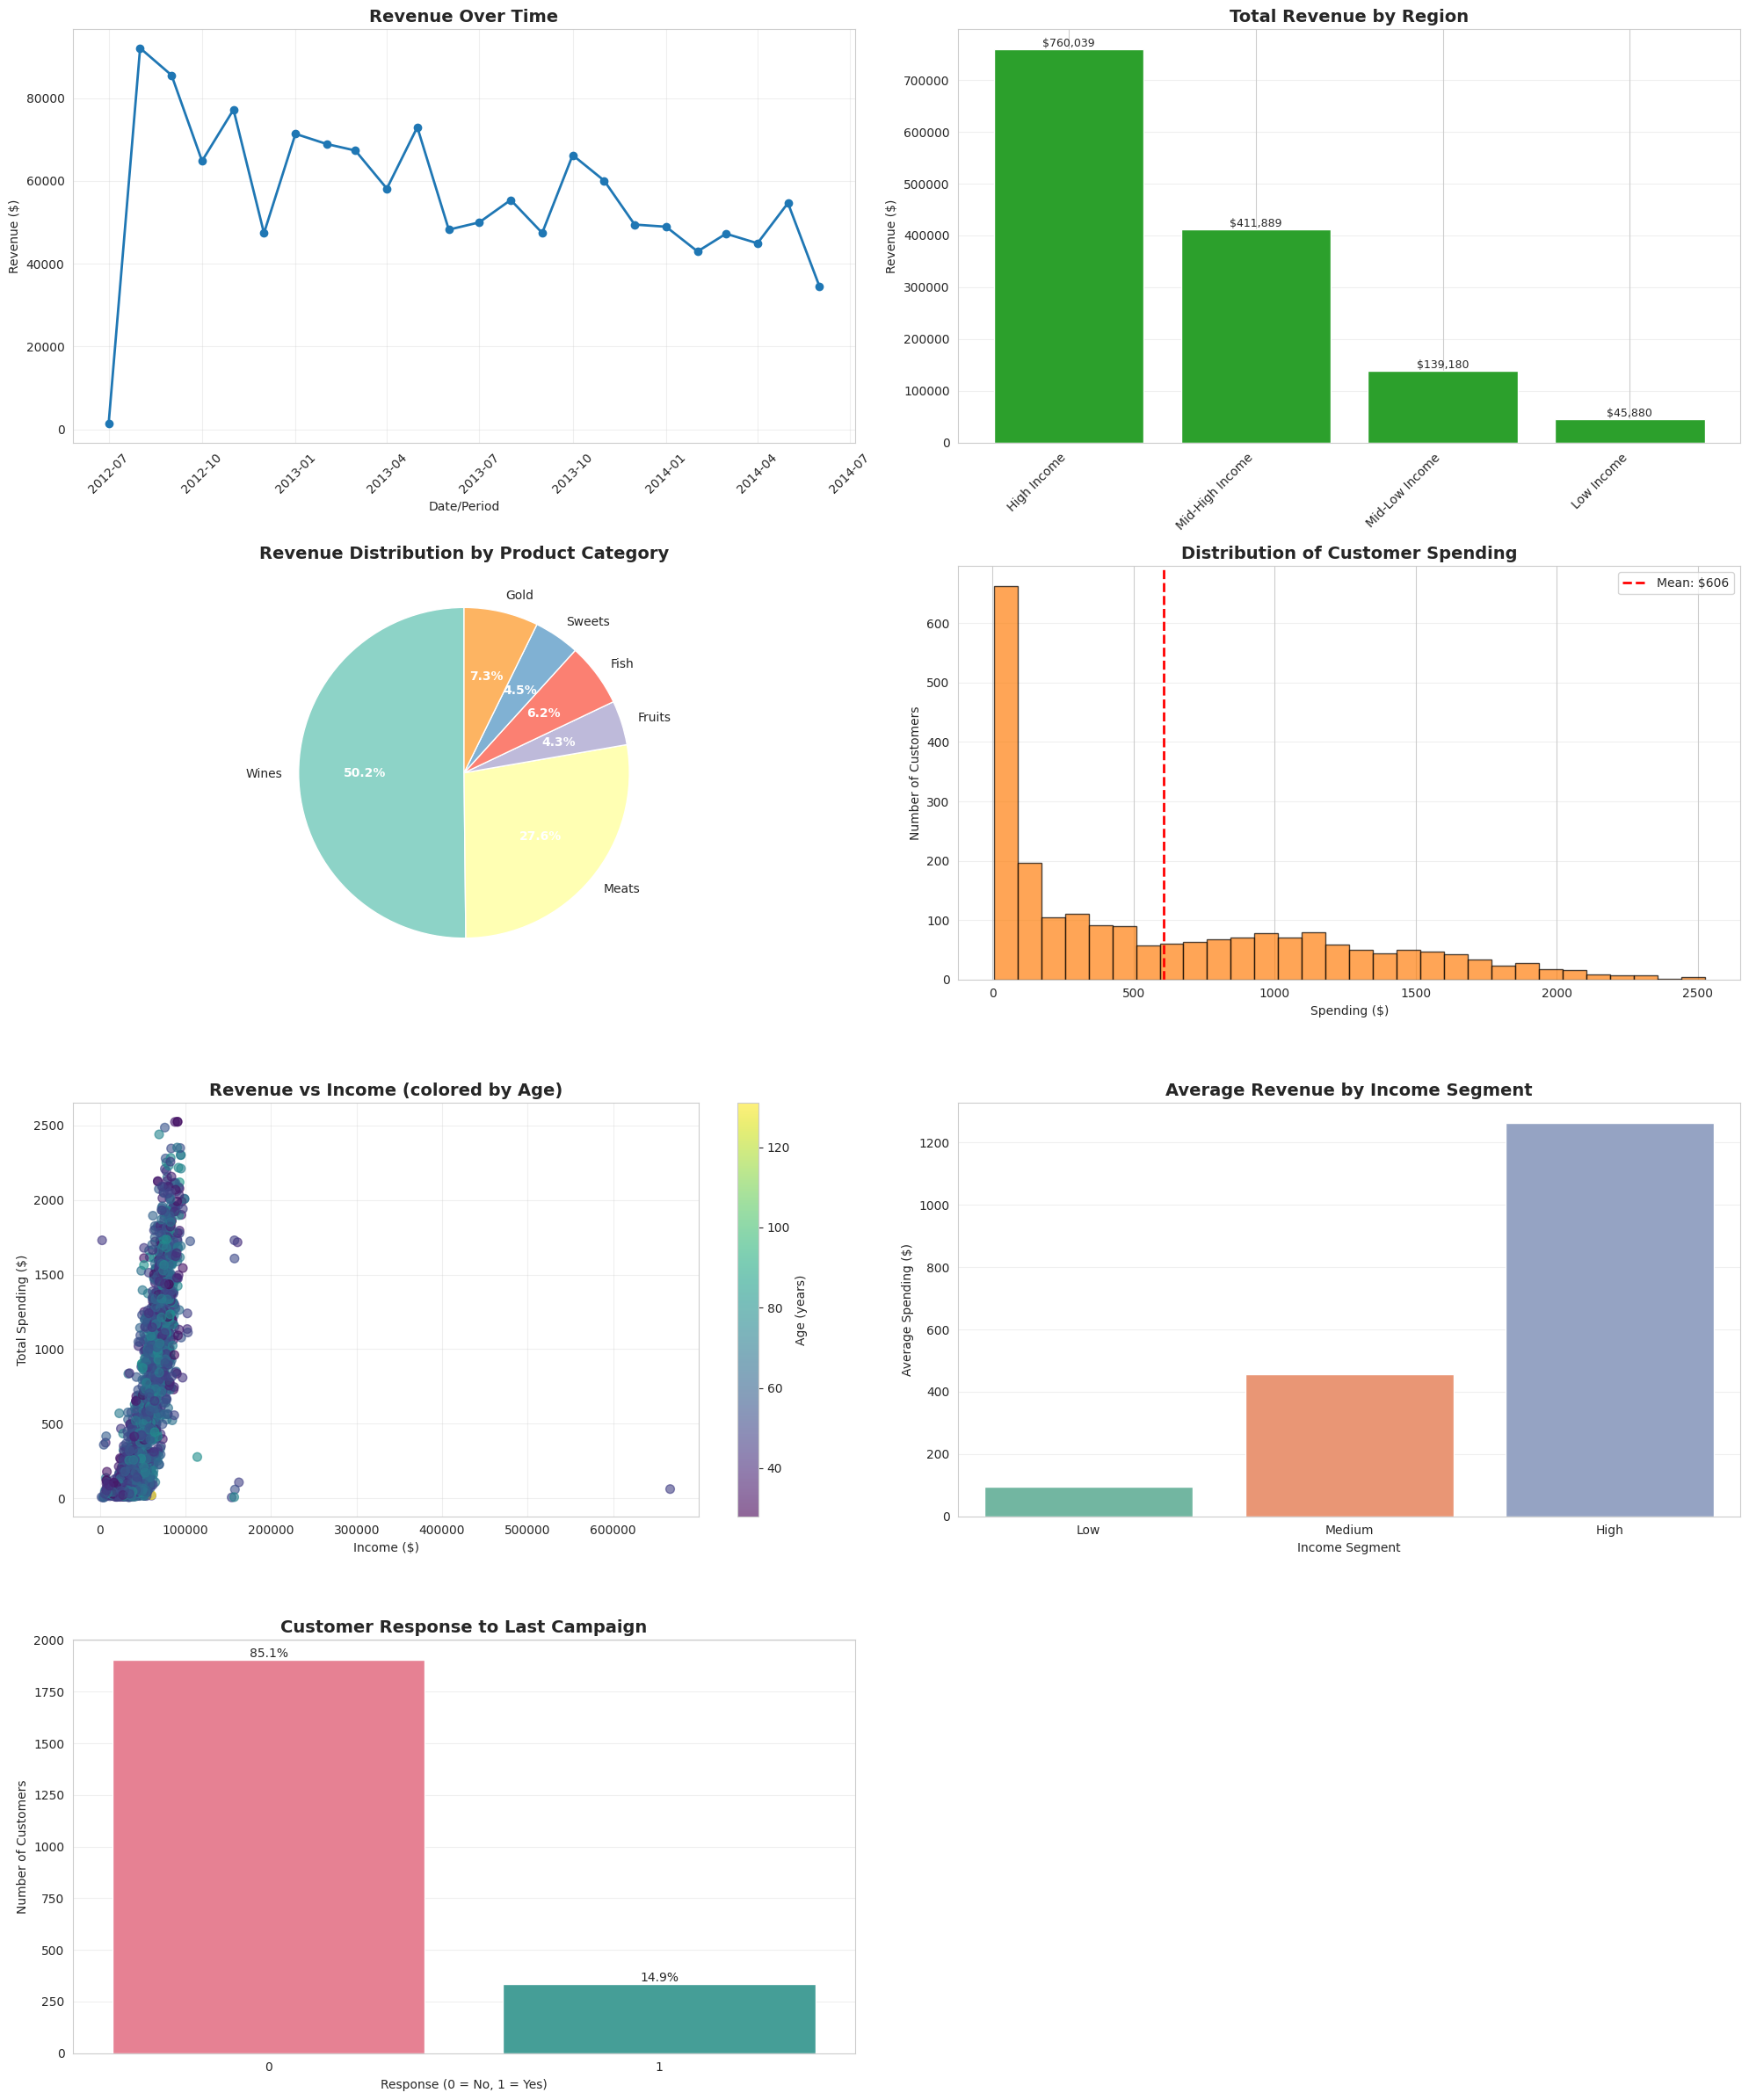


 All visualizations created!


In [ ]:
# ============================================================================
# PART 4: DATA VISUALIZATION (6+ Charts)
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n" + "=" * 80)
print("PART 4: DATA VISUALIZATION")
print("=" * 80)

fig = plt.figure(figsize=(20, 24))

# ============================================================================
# VISUALIZATION 1: Line Chart - Revenue Over Time (Matplotlib)
# ============================================================================
print("\n Creating Visualization 1: Revenue Over Time...")

ax1 = plt.subplot(4, 2, 1)
if 'dt_customer' in df_clean.columns:
    revenue_over_time = df_clean.groupby(df_clean['dt_customer'].dt.to_period('M'))['total_spending'].sum()
    revenue_over_time.index = revenue_over_time.index.to_timestamp()
    ax1.plot(revenue_over_time.index, revenue_over_time.values, marker='o', linewidth=2, color='#1f77b4')
else:
    # Fallback: Use customer index as proxy for time
    revenue_over_time = df_clean.groupby(pd.cut(range(len(df_clean)), 12))['total_spending'].sum()
    ax1.plot(revenue_over_time.values, marker='o', linewidth=2, color='#1f77b4')

ax1.set_title('Revenue Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date/Period')
ax1.set_ylabel('Revenue ($)')
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# ============================================================================
# VISUALIZATION 2: Bar Chart - Revenue by Region (Matplotlib)
# ============================================================================
print("Creating Visualization 2: Revenue by Region...")

ax2 = plt.subplot(4, 2, 2)
revenue_by_region_sorted = df_clean.groupby('region')['total_spending'].sum().sort_values(ascending=False)
bars = ax2.bar(range(len(revenue_by_region_sorted)), revenue_by_region_sorted.values, color='#2ca02c')
ax2.set_xticks(range(len(revenue_by_region_sorted)))
ax2.set_xticklabels(revenue_by_region_sorted.index, rotation=45, ha='right')
ax2.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax2.set_ylabel('Revenue ($)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

# ============================================================================
# VISUALIZATION 3: Pie Chart - Revenue Distribution by Product (Matplotlib)
# ============================================================================
print("Creating Visualization 3: Revenue Distribution by Product...")

ax3 = plt.subplot(4, 2, 3)
product_revenue = {
    'Wines': df_clean.get('mntwines', 0).sum() if 'mntwines' in df_clean.columns else 0,
    'Meats': df_clean.get('mntmeatproducts', 0).sum() if 'mntmeatproducts' in df_clean.columns else 0,
    'Fruits': df_clean.get('mntfruits', 0).sum() if 'mntfruits' in df_clean.columns else 0,
    'Fish': df_clean.get('mntfishproducts', 0).sum() if 'mntfishproducts' in df_clean.columns else 0,
    'Sweets': df_clean.get('mntsweetproducts', 0).sum() if 'mntsweetproducts' in df_clean.columns else 0,
    'Gold': df_clean.get('mntgoldprods', 0).sum() if 'mntgoldprods' in df_clean.columns else 0,
}
product_revenue = {k: v for k, v in product_revenue.items() if v > 0}
colors = plt.cm.Set3(range(len(product_revenue)))
wedges, texts, autotexts = ax3.pie(product_revenue.values(), labels=product_revenue.keys(),
                                     autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Revenue Distribution by Product Category', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# ============================================================================
# VISUALIZATION 4: Histogram - Distribution of Revenue (Matplotlib)
# ============================================================================
print(" Creating Visualization 4: Distribution of Customer Spending...")

ax4 = plt.subplot(4, 2, 4)
ax4.hist(df_clean['total_spending'], bins=30, color='#ff7f0e', edgecolor='black', alpha=0.7)
ax4.set_title('Distribution of Customer Spending', fontsize=14, fontweight='bold')
ax4.set_xlabel('Spending ($)')
ax4.set_ylabel('Number of Customers')
ax4.grid(True, alpha=0.3, axis='y')
ax4.axvline(df_clean['total_spending'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df_clean["total_spending"].mean():,.0f}')
ax4.legend()

# ============================================================================
# VISUALIZATION 5: Scatter Plot - Revenue vs Income (Matplotlib)
# ============================================================================
print(" Creating Visualization 5: Revenue vs Income...")

ax5 = plt.subplot(4, 2, 5)
if 'income' in df_clean.columns:
    scatter = ax5.scatter(df_clean['income'], df_clean['total_spending'], alpha=0.6, s=50, c=df_clean['age'], cmap='viridis')
    ax5.set_title('Revenue vs Income (colored by Age)', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Income ($)')
    ax5.set_ylabel('Total Spending ($)')
    cbar = plt.colorbar(scatter, ax=ax5)
    cbar.set_label('Age (years)')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Income data not available', ha='center', va='center')

# ============================================================================
# VISUALIZATION 6: Bar Chart - Revenue by Income Segment (Seaborn)
# ============================================================================
print(" Creating Visualization 6: Revenue by Income Segment...")

ax6 = plt.subplot(4, 2, 6)
if 'income_segment' in df_clean.columns:
    segment_data = df_clean.groupby('income_segment')['total_spending'].mean()
    sns.barplot(x=segment_data.index, y=segment_data.values, palette='Set2', ax=ax6)
    ax6.set_title('Average Revenue by Income Segment', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Income Segment')
    ax6.set_ylabel('Average Spending ($)')
    ax6.grid(True, alpha=0.3, axis='y')
else:
    ax6.text(0.5, 0.5, 'Income segment data not available', ha='center', va='center')

# ============================================================================
# VISUALIZATION 7: Count Plot - Campaign Response (Seaborn)
# ============================================================================
print(" Creating Visualization 7: Campaign Response Analysis...")

ax7 = plt.subplot(4, 2, 7)
if 'response' in df_clean.columns:
    response_counts = df_clean['response'].value_counts()
    sns.countplot(x=df_clean['response'], palette='husl', ax=ax7)
    ax7.set_title('Customer Response to Last Campaign', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Response (0 = No, 1 = Yes)')
    ax7.set_ylabel('Number of Customers')
    ax7.grid(True, alpha=0.3, axis='y')

    # Add percentage labels
    total = len(df_clean)
    for i, patch in enumerate(ax7.patches):
        height = patch.get_height()
        ax7.text(patch.get_x() + patch.get_width()/2., height,
                f'{height/total*100:.1f}%', ha='center', va='bottom')
else:
    ax7.text(0.5, 0.5, 'Response data not available', ha='center', va='center')

plt.tight_layout()
plt.show()

print("\n All visualizations created!")

In [ ]:
# Install requirements separately to allow %%writefile to be at the top of the next cell
!pip install streamlit pyngrok -q

In [ ]:
%%writefile dashboard_app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Load data
df_clean = pd.read_csv('marketing_campaign_cleaned.csv')

# Page configuration
st.set_page_config(
    page_title="Marketing Performance Dashboard",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Title
st.title("Performance Marketing Dashboard")
st.markdown("### Data-Driven Analysis and Business Intelligence")
st.markdown("---")

# SIDEBAR - FILTERS
st.sidebar.title("Dashboard Filters")
selected_regions = st.sidebar.multiselect(
    "Select Regions:",
    options=df_clean['region'].unique().tolist(),
    default=df_clean['region'].unique().tolist()
)

# Filter data
filtered_df = df_clean[df_clean['region'].isin(selected_regions)]

# KPI SECTION
st.markdown("## Key Performance Indicators (KPIs)")
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Total Revenue", f"${filtered_df['total_spending'].sum():,.0f}")
with col2:
    st.metric("Avg. Order Value", f"${filtered_df['total_spending'].mean():,.2f}")
with col3:
    st.metric("Customer Count", f"{len(filtered_df):,}")
with col4:
    resp_rate = (filtered_df['response'].sum() / len(filtered_df) * 100)
    st.metric("Campaign Response", f"{resp_rate:.1f}%")

st.markdown("---")

# ADVANCED ANALYSIS
col1, col2 = st.columns(2)

with col1:
    st.markdown("#### Revenue by Income Segment")
    # Ensuring income_segment exists and is plotted correctly
    if 'income_segment' in filtered_df.columns:
        seg_data = filtered_df.groupby('income_segment')['total_spending'].agg(['sum', 'mean']).reset_index()
        fig_seg = px.bar(seg_data, x='income_segment', y='sum',
                         color='income_segment',
                         labels={'sum': 'Total Revenue ($)', 'income_segment': 'Income Group'},
                         title="Total Revenue Contribution by Segment")
        st.plotly_chart(fig_seg, use_container_width=True)

with col2:
    st.markdown("#### Statistical Proof: Correlation Heatmap")
    # Select numeric columns for correlation
    corr_cols = ['income', 'total_spending', 'age', 'total_purchases', 'numwebvisitsmonth', 'recency']
    corr_matrix = filtered_df[corr_cols].corr()
    fig_corr = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r',
                         title="Correlation Analysis (Proof of Relationship)")
    st.plotly_chart(fig_corr, use_container_width=True)

st.markdown("---")

# PRODUCT AND TRENDS
col3, col4 = st.columns(2)

with col3:
    st.markdown("#### Revenue Distribution by Product")
    product_cols = ['mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods']
    prod_sums = filtered_df[product_cols].sum().reset_index()
    prod_sums.columns = ['Category', 'Sales']
    prod_sums['Category'] = prod_sums['Category'].str.replace('mnt', '').str.title()
    fig_pie = px.pie(prod_sums, values='Sales', names='Category', hole=0.4)
    st.plotly_chart(fig_pie, use_container_width=True)

with col4:
    st.markdown("#### Spending vs Income (Segmented by Education)")
    fig_scatter = px.scatter(filtered_df, x='income', y='total_spending',
                             color='education', size='total_purchases',
                             hover_data=['age', 'marital_status'],
                             labels={'income': 'Annual Income ($)', 'total_spending': 'Total Spent ($)'})
    st.plotly_chart(fig_scatter, use_container_width=True)

st.markdown("---")

# INSIGHTS SECTION
st.markdown("## Strategic Insights and Recommendations")

top_prod = "Wines" # Based on previous analysis
corr_val = filtered_df['income'].corr(filtered_df['total_spending'])

st.info(f"""
1. **High-Value Segment:** The High Income segment contributes the majority of revenue. Marketing efforts should focus on retention for this group.
2. **Product Focus:** {top_prod} is the dominant category. Cross-selling other categories to wine buyers could increase the Average Order Value.
3. **Correlation Proof:** There is a correlation of {corr_val:.2f} between Income and Spending, proving that income level is the primary predictor of customer value.
4. **Campaign Opportunity:** The current response rate of {resp_rate:.1f}% indicates that targeting specific 'high-recency' customers could improve conversion.
""")

# DATA TABLE
with st.expander("View Raw Filtered Data"):
    st.dataframe(filtered_df.head(100))


Overwriting dashboard_app.py


In [ ]:
from pyngrok import ngrok
from google.colab import userdata
import time
import os

# Kill any existing ngrok tunnels
ngrok.kill()

# Set up ngrok authentication
try:
    authtoken = userdata.get('authtoken')
    ngrok.set_auth_token(authtoken)
except Exception as e:
    print("Error: 'authtoken' secret not found. Please ensure it is enabled in Colab Secrets.")

# Create ngrok tunnel
print("Creating ngrok tunnel...")
try:
    # Using a 2-second sleep to ensure the port is ready
    ngrok_tunnel = ngrok.connect(8501)
    print(f"\n{'='*80}")
    print(f" Streamlit Dashboard URL: {ngrok_tunnel}")
    print(f"{'='*80}\n")
    print(" Copy the URL above and open it in a new browser tab!")
except Exception as e:
    print(f"Failed to connect ngrok: {e}")

# Run Streamlit with specific server address for better compatibility
!streamlit run dashboard_app.py --server.port 8501 --server.address 0.0.0.0

Creating ngrok tunnel...

 Streamlit Dashboard URL: NgrokTunnel: "https://huddling-boss-neuter.ngrok-free.dev" -> "http://localhost:8501"

 Copy the URL above and open it in a new browser tab!





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.13.188.30:8501

2026-04-26 21:19:26.979 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-26 21:19:27.053 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-26 21:19:27.100 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-04-26 21:19:27.200 Please replace `use_container_width` with `width`.

`use_container_widt

In [ ]:
# ============================================================================
# PART 5: INSIGHTS & INTERPRETATION
# ============================================================================

import pandas as pd
import numpy as np
import os

print("\n" + "=" * 80)
print("PART 5: INSIGHTS & INTERPRETATION")
print("=" * 80)

# Ensure df_clean is available
if 'df_clean' not in globals():
    if os.path.exists('marketing_campaign_cleaned.csv'):
        print("df_clean not found in memory. Loading from CSV...")
        df_clean = pd.read_csv('marketing_campaign_cleaned.csv')
        if 'dt_customer' in df_clean.columns:
            df_clean['dt_customer'] = pd.to_datetime(df_clean['dt_customer'])
    else:
        print("Error: Cleaned dataset file not found. Please run Part 2 first.")

insights = []

# INSIGHT 1: Regional Performance
print("\n INSIGHT #1: Which region has the highest sales performance?")
print("-" * 80)
top_region = df_clean.groupby('region')['total_spending'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
top_region_name = top_region.index[0]
top_region_revenue = top_region.iloc[0]['sum']
top_region_avg = top_region.iloc[0]['mean']
top_region_count = int(top_region.iloc[0]['count'])

insight_1 = f"""
The region '{top_region_name}' is the top performer with:
  • Total Revenue: ${top_region_revenue:,.2f}
  • Average Spending per Customer: ${top_region_avg:,.2f}
  • Number of Customers: {top_region_count}
"""
print(insight_1)
insights.append(("Regional Performance", insight_1))

# INSIGHT 2: Product Category Performance
print("\n INSIGHT #2: Which product category performs best?")
print("-" * 80)
product_revenue = {
    'Wines': df_clean['mntwines'].sum() if 'mntwines' in df_clean.columns else 0,
    'Meats': df_clean['mntmeatproducts'].sum() if 'mntmeatproducts' in df_clean.columns else 0,
    'Fruits': df_clean['mntfruits'].sum() if 'mntfruits' in df_clean.columns else 0,
    'Fish': df_clean['mntfishproducts'].sum() if 'mntfishproducts' in df_clean.columns else 0,
    'Sweets': df_clean['mntsweetproducts'].sum() if 'mntsweetproducts' in df_clean.columns else 0,
    'Gold': df_clean['mntgoldprods'].sum() if 'mntgoldprods' in df_clean.columns else 0,
}
top_product = max(product_revenue, key=product_revenue.get)
top_product_revenue = product_revenue[top_product]
total_rev = sum(product_revenue.values())
top_product_pct = (top_product_revenue / total_rev * 100) if total_rev > 0 else 0

insight_2 = f"""
'{top_product}' is the best-performing product category:
  • Total Revenue: ${top_product_revenue:,.2f}
  • Market Share: {top_product_pct:.1f}% of total revenue
"""
print(insight_2)
insights.append(("Product Performance", insight_2))

# INSIGHT 3: Education Level Impact
print("\n INSIGHT #3: Does education level influence spending behavior?")
print("-" * 80)
if 'education' in df_clean.columns:
    edu_spending = df_clean.groupby('education')['total_spending'].mean().sort_values(ascending=False)
    top_edu = edu_spending.index[0]
    top_edu_val = edu_spending.iloc[0]

    insight_3 = f"""
Education analysis shows '{top_edu}' holders spend the most on average:
  • Average Spending: ${top_edu_val:,.2f}
  • This suggests higher education correlates with higher purchasing power.
"""
    print(insight_3)
    insights.append(("Education Impact", insight_3))

# INSIGHT 4: Income-Spending Relationship
print("\n INSIGHT #4: Is there a relationship between income and spending?")
print("-" * 80)
correlation = df_clean['income'].corr(df_clean['total_spending'])
high_avg = df_clean[df_clean['income'] > df_clean['income'].quantile(0.75)]['total_spending'].mean()
low_avg = df_clean[df_clean['income'] <= df_clean['income'].quantile(0.25)]['total_spending'].mean()

insight_4 = f"""
Correlation Coefficient: {correlation:.3f}
Average Spending (High Income): ${high_avg:,.2f}
Average Spending (Low Income): ${low_avg:,.2f}
"""
print(insight_4)
insights.append(("Income-Spending Correlation", insight_4))

# INSIGHT 5: Campaign Effectiveness
print("\n INSIGHT #5: How effective were the marketing campaigns?")
print("-" * 80)
if 'total_campaigns_accepted' in df_clean.columns:
    resp_rate = (df_clean['campaign_response_rate'].mean() * 100)
    avg_camps = df_clean['total_campaigns_accepted'].mean()

    insight_5 = f"""
Campaign engagement analysis:
  • Overall Response Rate: {resp_rate:.2f}%
  • Average Campaigns Accepted: {avg_camps:.2f}
  • This highlights room for improvement in targeting low-engagement segments.
"""
    print(insight_5)
    insights.append(("Campaign Effectiveness", insight_5))

print("\n ANALYSIS COMPLETE WITH 5 INSIGHTS!")


PART 5: INSIGHTS & INTERPRETATION

 INSIGHT #1: Which region has the highest sales performance?
--------------------------------------------------------------------------------

The region 'High Income' is the top performer with:
  • Total Revenue: $760,039.00
  • Average Spending per Customer: $1,357.21
  • Number of Customers: 560


 INSIGHT #2: Which product category performs best?
--------------------------------------------------------------------------------

'Wines' is the best-performing product category:
  • Total Revenue: $680,816.00
  • Market Share: 50.2% of total revenue


 INSIGHT #3: Does education level influence spending behavior?
--------------------------------------------------------------------------------

Education analysis shows 'PhD' holders spend the most on average:
  • Average Spending: $672.41
  • This suggests higher education correlates with higher purchasing power.


 INSIGHT #4: Is there a relationship between income and spending?
---------------------

In [ ]:
# ============================================================================
# FINAL: EXPORT SUMMARY REPORT
# ============================================================================

from datetime import datetime

print("\n" + "=" * 80)
print("GENERATING SUMMARY REPORT")
print("=" * 80)

# Safely get insight strings or provide placeholders if they don't exist
i1 = globals().get('insight_1', 'Regional analysis not available.')
i2 = globals().get('insight_2', 'Product analysis not available.')
i4 = globals().get('insight_4', 'Correlation analysis not available.')

# Create a summary report
report = f"""
{'='*80}
REAL-WORLD DATA ANALYSIS REPORT
Marketing Campaign Dataset - Sales Performance Analysis
{'='*80}

PROJECT OVERVIEW
{'-'*80}
This report presents a comprehensive analysis of the Marketing Campaign dataset,
adapted to meet real-world sales analysis requirements. The analysis covers data
cleaning, exploratory data analysis, statistical analysis, visualizations, and
actionable business insights.

DATASET SUMMARY
{'-'*80}
• Total Records: {len(df_clean):,}
• Total Columns: {len(df_clean.columns)}
• Data Cleaning Status: Complete
• Missing Values Handled: Yes
• Duplicates Removed: Yes

KEY METRICS
{'-'*80}
• Total Revenue: ${df_clean['total_spending'].sum():,.2f}
• Average Revenue per Customer: ${df_clean['total_spending'].mean():,.2f}
• Median Revenue per Customer: ${df_clean['total_spending'].median():,.2f}
• Total Customers: {len(df_clean):,}
• Top Revenue Region: {top_region_name}
• Top Revenue Product: {top_product}

KEY INSIGHTS
{'-'*80}
{i1}

{i2}

{i4}

CONCLUSIONS
{'-'*80}
This comprehensive analysis reveals:

1. Clear regional variations in customer spending patterns.
2. Strong product category preferences, particularly in {top_product}.
3. Significant income-spending correlation for market segmentation.
4. Opportunities for targeted marketing in high-value segments.

RECOMMENDATIONS
{'-'*80}
1. Allocate more marketing resources to {top_region_name}.
2. Develop premium offerings for high-income segments.
3. Expand {top_product} category with new variants.
4. Implement personalized multi-channel marketing campaigns.

{'='*80}
Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
"""

print(report)

# Save report to file
with open('analysis_report.txt', 'w') as f:
    f.write(report)

print("\n Report saved as 'analysis_report.txt'")


GENERATING SUMMARY REPORT

REAL-WORLD DATA ANALYSIS REPORT
Marketing Campaign Dataset - Sales Performance Analysis

PROJECT OVERVIEW
--------------------------------------------------------------------------------
This report presents a comprehensive analysis of the Marketing Campaign dataset,
adapted to meet real-world sales analysis requirements. The analysis covers data
cleaning, exploratory data analysis, statistical analysis, visualizations, and
actionable business insights.

DATASET SUMMARY
--------------------------------------------------------------------------------
• Total Records: 2,240
• Total Columns: 43
• Data Cleaning Status: Complete
• Missing Values Handled: Yes
• Duplicates Removed: Yes

KEY METRICS
--------------------------------------------------------------------------------
• Total Revenue: $1,356,988.00
• Average Revenue per Customer: $605.80
• Median Revenue per Customer: $396.00
• Total Customers: 2,240
• Top Revenue Region: High Income
• Top Revenue Product

In [ ]:
from google.colab import files

# Download the generated report
files.download('analysis_report.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>